In [1]:
import numpy as np
import os
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*XGBoost is not compiled with CUDA support.*"
)

In [2]:
with open('routerbench/routerbench_raw.pkl', 'rb') as file:
    data_raw = pickle.load(file)

with open('routerbench/routerbench_0shot.pkl', 'rb') as file:
    data0 = pickle.load(file)

with open('routerbench/routerbench_5shot.pkl', 'rb') as file:
    data5 = pickle.load(file)

with open('routerbench/data/embedding_cache_all-MiniLM-L12-v2.pkl', 'rb') as file:
    embed_all = pickle.load(file)

# with open('routerbench/data/routerbench/input_wide__04-11-04__routerbench.pkl', 'rb') as file:
#     embed_wide = pickle.load(file)

/tmp/ipykernel_22451/724477448.py:2: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  data_raw = pickle.load(file)
/tmp/ipykernel_22451/724477448.py:5: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case

In [3]:
embeddings = [i['embedding'] for i in embed_all]
np.array(embeddings).shape

(36511, 384)

In [4]:
to_exclude = []

for c in pd.unique(data5['eval_name']):
    if c.startswith("mmlu"):
        continue
    elif c.startswith('mtbench'):
        continue
    elif c.startswith('mbpp'):
        continue
    elif c.startswith('hellaswag'):
        continue
    elif c.startswith('winogrande'):
        continue
    elif c.startswith('arc-challenge'):
        continue
    elif c.startswith('grade-school-math'):
        continue
    else:
        to_exclude.append(c)

to_exclude


['Chinese_character_riddles',
 'abstract2title',
 'accounting_audit',
 'bias_detection',
 'chinese-lantern-riddles',
 'chinese-remainder-theorem',
 'chinese_ancient_masterpieces_dynasty',
 'chinese_ancient_poetry',
 'chinese_chu_ci',
 'chinese_famous_novel',
 'chinese_hard_translations',
 'chinese_homonym',
 'chinese_idioms',
 'chinese_modern_poem_identification',
 'chinese_poem',
 'chinese_shi_jing',
 'chinese_song_ci',
 'chinese_tang_poetries',
 'chinese_zodiac',
 'consensus_summary',
 'test-match']

In [5]:
llms = ['WizardLM/WizardLM-13B-V1.2', 'claude-instant-v1', 'claude-v1', 'claude-v2', 'gpt-3.5-turbo-1106',
       'gpt-4-1106-preview', 'meta/code-llama-instruct-34b-chat',
       'meta/llama-2-70b-chat', 'mistralai/mistral-7b-chat',
       'mistralai/mixtral-8x7b-chat', 'zero-one-ai/Yi-34B-Chat']

llms_short = ['WizardLM 13B', 'Claude Instant v1', 'Claude v1', 'Claude v2', 'GPT-3.5',
       'GPT-4', 'Code Llama 34b',
       'Llama 70b', 'Mistral 7b',
       'Mixtral 8x7b', 'Yi 34B']

In [6]:
from sklearn.model_selection import train_test_split


def get_nan_row_indices(arr):
    """
    Returns the indices of rows containing NaN values in a NumPy array.

    Args:
        arr (np.ndarray): The input NumPy array.

    Returns:
        np.ndarray: An array of row indices containing NaN values.
    """
    nan_mask = np.isnan(arr)
    row_has_nan = np.any(nan_mask, axis=1)
    return np.where(row_has_nan)[0]


filter_categories = 1

if filter_categories:
    mask_to_keep = ~data5['eval_name'].isin(to_exclude)
    data5 = data5[mask_to_keep].reset_index()

    embeddings_array = np.array(embeddings)
    embeddings = embeddings_array[mask_to_keep].tolist()

y_cost = np.zeros((len(embeddings), 11))
y_acc = np.zeros((len(embeddings), 11))

llm_acc_cost = ['WizardLM/WizardLM-13B-V1.2',
       'claude-instant-v1', 'claude-v1', 'claude-v2', 'gpt-3.5-turbo-1106',
       'gpt-4-1106-preview', 'meta/code-llama-instruct-34b-chat',
       'meta/llama-2-70b-chat', 'mistralai/mistral-7b-chat',
       'mistralai/mixtral-8x7b-chat', 'zero-one-ai/Yi-34B-Chat',
       'WizardLM/WizardLM-13B-V1.2|total_cost', 'claude-instant-v1|total_cost',
       'claude-v1|total_cost', 'claude-v2|total_cost',
       'gpt-3.5-turbo-1106|total_cost',
       'gpt-4-1106-preview|total_cost', 'meta/code-llama-instruct-34b-chat|total_cost', 'meta/llama-2-70b-chat|total_cost',
       'mistralai/mistral-7b-chat|total_cost', 'mistralai/mixtral-8x7b-chat|total_cost',
       'zero-one-ai/Yi-34B-Chat|total_cost']

for i in range(len(embeddings)):
    for j in range(11):
        y_cost[i, j] = data5[llm_acc_cost[j+11]][i]
        y_acc[i, j] = data5[llm_acc_cost[j]][i]

eval_data = data5['eval_name']

indices_to_delete = get_nan_row_indices(y_acc)
embeddings_clean = np.delete(embeddings, indices_to_delete, axis=0)
y_cost_clean = np.delete(y_cost, indices_to_delete, axis=0)
y_acc_clean = np.delete(y_acc, indices_to_delete, axis=0)
eval_data_clean = eval_data.drop(eval_data.index[indices_to_delete]).reset_index(drop=True)


x_train, x_test, y_acc_train, y_acc_test, y_cost_train, y_cost_test, eval_train, eval_test = train_test_split(embeddings_clean, y_acc_clean, y_cost_clean, eval_data_clean, stratify=eval_data_clean, test_size = 0.2, random_state=42)


In [ ]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor
from skactiveml.regressor import NICKernelRegressor

def score_auc(y_acc_test, y_cost_test, y_acc_pred, y_cost_pred, lam):
    n = y_acc_test.shape[0]
    y_cost_pred_ = y_cost_pred / np.max(y_cost_pred)
    y_cost_test_ = y_cost_test/np.max(y_cost_test)
    model_idx = ((1 - lam) * y_acc_pred - lam * y_cost_pred_).argmax(axis = 1)
    final_acc = np.zeros(n)
    final_cost = np.zeros(n)
    final_acc = y_acc_test[np.arange(n), model_idx]
    final_cost = y_cost_test_[np.arange(n), model_idx]
    return np.mean(final_acc), np.mean(final_cost)

lambdas = np.arange(0, 1.001, 0.0001)

# Oracle baseline
acc_oracle = np.zeros(len(lambdas))
cost_oracle = np.zeros(len(lambdas))
y_acc_pred_oracle = y_acc_test
y_cost_pred_oracle = y_cost_test

for i, lam in enumerate(lambdas):
    acc_oracle[i], cost_oracle[i] = score_auc(
      y_acc_test, y_cost_test, y_acc_pred_oracle, y_cost_pred_oracle, lam
    )

# NICKernelRegressor - Multi-Output
print("Training NICKernel Multi-Output model...")
nick_multi = MultiOutputRegressor(NICKernelRegressor(metric_dict={'gamma': 15.0}))
nick_multi.fit(x_train, y_acc_train)
y_acc_pred_nick_multi = nick_multi.predict(x_test)

acc_nick_multi = np.zeros(len(lambdas))
cost_nick_multi = np.zeros(len(lambdas))

for i, lam in enumerate(lambdas):
    acc_nick_multi[i], cost_nick_multi[i] = score_auc(
      y_acc_test, y_cost_test, y_acc_pred_nick_multi, y_cost_test, lam
    )
print("✓ NICKernel Multi-Output Done!\n")

# XGBoost - Multi-Output
print("Training XGBoost Multi-Output model...")
xgb_reg = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=2,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1e-3,
    reg_lambda=1.0,
    gamma=0.0,
    max_bin=256,
    random_state=42,
)

xgb_multi = MultiOutputRegressor(xgb_reg)
xgb_multi.fit(x_train, y_acc_train)
y_acc_pred_xgb = xgb_multi.predict(x_test)

acc_xgb = np.zeros(len(lambdas))
cost_xgb = np.zeros(len(lambdas))

for i, lam in enumerate(lambdas):
    acc_xgb[i], cost_xgb[i] = score_auc(
      y_acc_test, y_cost_test, y_acc_pred_xgb, y_cost_test, lam
    )
print("✓ XGBoost Multi-Output Done!\n")

# Random Forest - Multi-Output
# print("Training Random Forest Multi-Output model...")
# rf_reg = RandomForestRegressor(
#     n_estimators=500,
#     max_depth=12,
#     min_samples_split=5,
#     min_samples_leaf=2,
#     max_features='sqrt',
#     bootstrap=True,
#     n_jobs=-1,
#     random_state=42
# )

# rf_multi = MultiOutputRegressor(rf_reg)
# rf_multi.fit(x_train, y_acc_train)
# y_acc_pred_rf = rf_multi.predict(x_test)

# acc_rf = np.zeros(len(lambdas))
# cost_rf = np.zeros(len(lambdas))

# for i, lam in enumerate(lambdas):
#     acc_rf[i], cost_rf[i] = score_auc(
#       y_acc_test, y_cost_test, y_acc_pred_rf, y_cost_test, lam
#     )
# print("✓ Random Forest Multi-Output Done!\n")

# Plotting
plt.figure(figsize=(12, 7))

plt.plot(cost_oracle, acc_oracle, 'b-', linewidth=2.5, label='Oracle Router (Ground Truth)')
plt.plot(cost_nick_multi, acc_nick_multi, 'green', linestyle='-', linewidth=2,
      label='NICKernel (Multi-Output)')
plt.plot(cost_xgb, acc_xgb, 'purple', linestyle='--', linewidth=2,
      label='XGBoost (Multi-Output)')
# plt.plot(cost_rf, acc_rf, 'orange', linestyle='-.', linewidth=2,
#       label='Random Forest (Multi-Output)')

# Plot individual LLM points
for i, llm in enumerate(llms_short):
    avg_acc = np.mean(y_acc_test[:, i])
    avg_cost = np.mean(y_cost_test[:, i]) / np.max(y_cost_test)
    plt.scatter(avg_cost, avg_acc, s=80, alpha=0.6)

plt.xlabel('Cost', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Router Baselines Comparison - Multi-Output Models', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print comparison statistics
print("\n" + "="*60)
print("MULTI-OUTPUT BASELINE COMPARISON RESULTS")
print("="*60)
print(f"Oracle:                      Mean Acc: {acc_oracle.mean():.4f}, Mean Cost: {cost_oracle.mean():.4f}")
print(f"NICKernel (Multi-Output):    Mean Acc: {acc_nick_multi.mean():.4f}, Mean Cost: {cost_nick_multi.mean():.4f}")
print(f"XGBoost (Multi-Output):      Mean Acc: {acc_xgb.mean():.4f}, Mean Cost: {cost_xgb.mean():.4f}")
# print(f"Random Forest (Multi-Output): Mean Acc: {acc_rf.mean():.4f}, Mean Cost: {cost_rf.mean():.4f}")
print("="*60)

# Calculate improvements relative to NICKernel as baseline
xgb_vs_nick = ((acc_xgb.mean() - acc_nick_multi.mean()) / acc_nick_multi.mean()) * 100
# rf_vs_nick = ((acc_rf.mean() - acc_nick_multi.mean()) / acc_nick_multi.mean()) * 100
# rf_vs_xgb = ((acc_rf.mean() - acc_xgb.mean()) / acc_xgb.mean()) * 100

print(f"\nXGBoost vs NICKernel:     {xgb_vs_nick:+.2f}% accuracy difference")
# print(f"Random Forest vs NICKernel: {rf_vs_nick:+.2f}% accuracy difference")
# print(f"Random Forest vs XGBoost:   {rf_vs_xgb:+.2f}% accuracy difference")

# Find best performer
best_models = {
  'NICKernel': acc_nick_multi.mean(),
  'XGBoost': acc_xgb.mean(),
  # 'Random Forest': acc_rf.mean()
}
best_model = max(best_models, key=best_models.get)
worst_model = min(best_models, key=best_models.get)

print(f"\nBest Performing Model:  {best_model} with {best_models[best_model]:.4f} mean accuracy")
print(f"Worst Performing Model: {worst_model} with {best_models[worst_model]:.4f} mean accuracy")
print(f"Performance Gap: {(best_models[best_model] - best_models[worst_model]):.4f}")

Training NICKernel Multi-Output model...
✓ NICKernel Multi-Output Done!

Training XGBoost Multi-Output model...


In [16]:
from skactiveml.regressor import NICKernelRegressor
from skactiveml.pool import GreedySamplingTarget
import os
# from datetime import datetime

def calculate_mse(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

llm_name_map = {}
for i in range(len(llms_short)):
    llm_name_map[llms[i]] = llms_short[i]

def active_learn_and_save_regressors(llms_to_train, x_train, y_train, directory, initial_batch_size=50, batch_size=50, gamma=15.0, save_interval=1, random_state=42):

    os.makedirs(directory, exist_ok=True)

    qs = GreedySamplingTarget(random_state=random_state)

    n_iterations = 150

    for llm in llms_to_train:
        # start_time = datetime.now()

        regressor = NICKernelRegressor(metric_dict={'gamma': gamma})
        idx = llms.index(llm)
        y_true = y_train[:, idx]
        y_labeled = np.full_like(y_true, np.nan)

        y_labeled[:initial_batch_size] = y_true[:initial_batch_size]
        regressor.fit(x_train, y_labeled)
        llm_short_name = llm_name_map[llm]
        check_point_path = f"{directory}/{llm_short_name}_{initial_batch_size}.pkl"
        with open(check_point_path, 'wb') as file:
            pickle.dump(regressor, file)

        for iter in range(n_iterations):
            # iter_start_time = datetime.now()

            query_idx, _ = qs.query(X=x_train, y=y_labeled, reg=regressor, fit_reg=True, return_utilities=True, batch_size=batch_size)
            y_labeled[query_idx] = y_true[query_idx]
            regressor.fit(x_train, y_labeled)

            if iter % save_interval == 0:
                labeled = initial_batch_size + ((iter+1) * batch_size)
                checkpoint_path = f"{directory}/{llm_short_name}_{labeled}.pkl"
                with open(checkpoint_path, 'wb') as file:
                    pickle.dump(regressor, file)

In [ ]:
active_learn_and_save_regressors(
    llms_to_train=['zero-one-ai/Yi-34B-Chat'],
    x_train=x_train,
    y_train=y_acc_train,
    directory='GSt_Nickernel_checkpoints',
    initial_batch_size=100,
    batch_size=50,
    gamma=15.0,
    save_interval=1,
    random_state=42
)

In [8]:
from skactiveml.regressor import SklearnRegressor
from xgboost import XGBRegressor

def DDQBC_active_learning_and_save_regressors_indices(
    x_train, y_train, y_cost_train, y_pred_baseline_train, directory,
    initial_batch_size=50, batch_size=50, save_interval=1,
    random_state=42, n_committee=10, n_iterations=150,
    llms=None, yi_name='zero-one-ai/Yi-34B-Chat',
    tau=1.0, epsilon=0.0,
    lambdas_acq=None,
):
    os.makedirs(directory, exist_ok=True)

    yi_idx = llms.index(yi_name)
    y_true = y_train[:, yi_idx].astype(float)
    y_labeled = np.full_like(y_true, np.nan, dtype=float)

    np.random.seed(random_state)
    initial_indices = np.random.choice(len(y_true), initial_batch_size, replace=False)
    y_labeled[initial_indices] = y_true[initial_indices]

    selection_order = list(initial_indices.tolist())

    committee = []
    for i in range(n_committee):
        xgb_model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state + i,
        )
        committee.append(SklearnRegressor(xgb_model, missing_label=np.nan))

    def retrain_committee(iter_no: int):
        labeled_indices = np.where(~np.isnan(y_labeled))[0]
        for i, model in enumerate(committee):
            rng = np.random.RandomState(random_state + i + iter_no * 1000)
            boot = rng.choice(labeled_indices, len(labeled_indices), replace=True)
            model.fit(x_train[boot], y_labeled[boot])

    def save_checkpoint(n_labeled, iter_no):
        path = f"{directory}/Yi_34B_{n_labeled}.pkl"
        with open(path, "wb") as f:
            pickle.dump(committee, f)

    if lambdas_acq is None:
        lambdas_acq = np.arange(0, 1.001, 0.0001)

    y_cost_train_norm = y_cost_train / np.max(y_cost_train)

    old_indices = [j for j in range(y_pred_baseline_train.shape[1]) if j != yi_idx]
    baseline_preds_no_yi = y_pred_baseline_train[:, old_indices]
    cost_norm_no_yi = y_cost_train_norm[:, old_indices]
    yi_cost_norm = y_cost_train_norm[:, yi_idx]

    retrain_committee(iter_no=0)
    save_checkpoint(n_labeled=initial_batch_size, iter_no=0)

    for it in range(n_iterations):
        remaining_unlabeled = np.sum(np.isnan(y_labeled))
        if remaining_unlabeled == 0:
            break

        actual_batch_size = min(batch_size, int(remaining_unlabeled))

        committee_preds = np.stack([m.predict(x_train) for m in committee], axis=1)

        unlabeled_indices = np.where(np.isnan(y_labeled))[0]
        n_unlabeled = len(unlabeled_indices)

        comm_preds_u = committee_preds[unlabeled_indices]
        baseline_u = baseline_preds_no_yi[unlabeled_indices]
        cost_u_old = cost_norm_no_yi[unlabeled_indices]
        yi_cost_u = yi_cost_norm[unlabeled_indices]

        dd_scores = np.zeros(n_unlabeled, dtype=np.float64)

        for lam in lambdas_acq:
            lam_f = float(lam)

            # Best existing competitor utility
            existing_utilities = (1 - lam_f) * baseline_u - lam_f * cost_u_old
            best_existing = existing_utilities.max(axis=1)

            # Committee utility estimates for Yi
            yi_utilities = (1 - lam_f) * comm_preds_u - lam_f * yi_cost_u[:, np.newaxis]

            # Binary votes and vote fraction
            p = (yi_utilities >= best_existing[:, np.newaxis]).astype(float).mean(axis=1)

            eps_log = 1e-12
            H = -p * np.log(p + eps_log) - (1 - p) * np.log(1 - p + eps_log)
            H[(p < eps_log) | (p > 1 - eps_log)] = 0.0

            # Utility margin
            yi_mean_utility = yi_utilities.mean(axis=1)
            delta = yi_mean_utility - best_existing

            # Capped margin weight
            g = np.minimum(np.abs(delta), tau)

            # Score for this lambda
            score_lam = H * g

            if epsilon > 0:
                max_yi = yi_utilities.max(axis=1)
                score_lam[max_yi < best_existing - epsilon] = 0.0

            dd_scores += score_lam

        dd_scores /= len(lambdas_acq)

        top_local = np.argsort(dd_scores)[::-1][:actual_batch_size]
        query_idx = unlabeled_indices[top_local]

        y_labeled[query_idx] = y_true[query_idx]
        selection_order.extend(query_idx.tolist())

        retrain_committee(iter_no=it + 1)

        if (it + 1) % save_interval == 0:
            n_labeled = initial_batch_size + ((it + 1) * batch_size)
            save_checkpoint(n_labeled=n_labeled, iter_no=it + 1)
            print(f"Iteration {it+1}: {n_labeled} samples saved")

In [ ]:
y_pred_baseline_train = xgb_multi.predict(x_train)
y_acc_pred_xgb_baseline_test = xgb_multi.predict(x_test)

DDQBC_active_learning_and_save_regressors_indices(
    x_train=x_train,
    y_train=y_acc_train,
    y_cost_train=y_cost_train,
    y_pred_baseline_train=y_pred_baseline_train,
    directory='ddqbc_XGB_checkpoints_yi',
    initial_batch_size=50,
    batch_size=50,
    save_interval=1,
    random_state=42,
    n_committee=10,
    n_iterations=300,
    llms=llms,
    yi_name='zero-one-ai/Yi-34B-Chat',
    tau=1.0,
    epsilon=0.0,
    lambdas_acq=None,
)

Iteration 1: 100 samples saved
Iteration 2: 150 samples saved
Iteration 3: 200 samples saved
Iteration 4: 250 samples saved
Iteration 5: 300 samples saved
Iteration 6: 350 samples saved
Iteration 7: 400 samples saved
Iteration 8: 450 samples saved
Iteration 9: 500 samples saved
Iteration 10: 550 samples saved
Iteration 11: 600 samples saved
Iteration 12: 650 samples saved
Iteration 13: 700 samples saved
Iteration 14: 750 samples saved
Iteration 15: 800 samples saved
Iteration 16: 850 samples saved
Iteration 17: 900 samples saved
Iteration 18: 950 samples saved
Iteration 19: 1000 samples saved
Iteration 20: 1050 samples saved
Iteration 21: 1100 samples saved
Iteration 22: 1150 samples saved
Iteration 23: 1200 samples saved
Iteration 24: 1250 samples saved
Iteration 25: 1300 samples saved
Iteration 26: 1350 samples saved
Iteration 27: 1400 samples saved
Iteration 37: 1900 samples saved
Iteration 38: 1950 samples saved
Iteration 39: 2000 samples saved
Iteration 40: 2050 samples saved
Iter

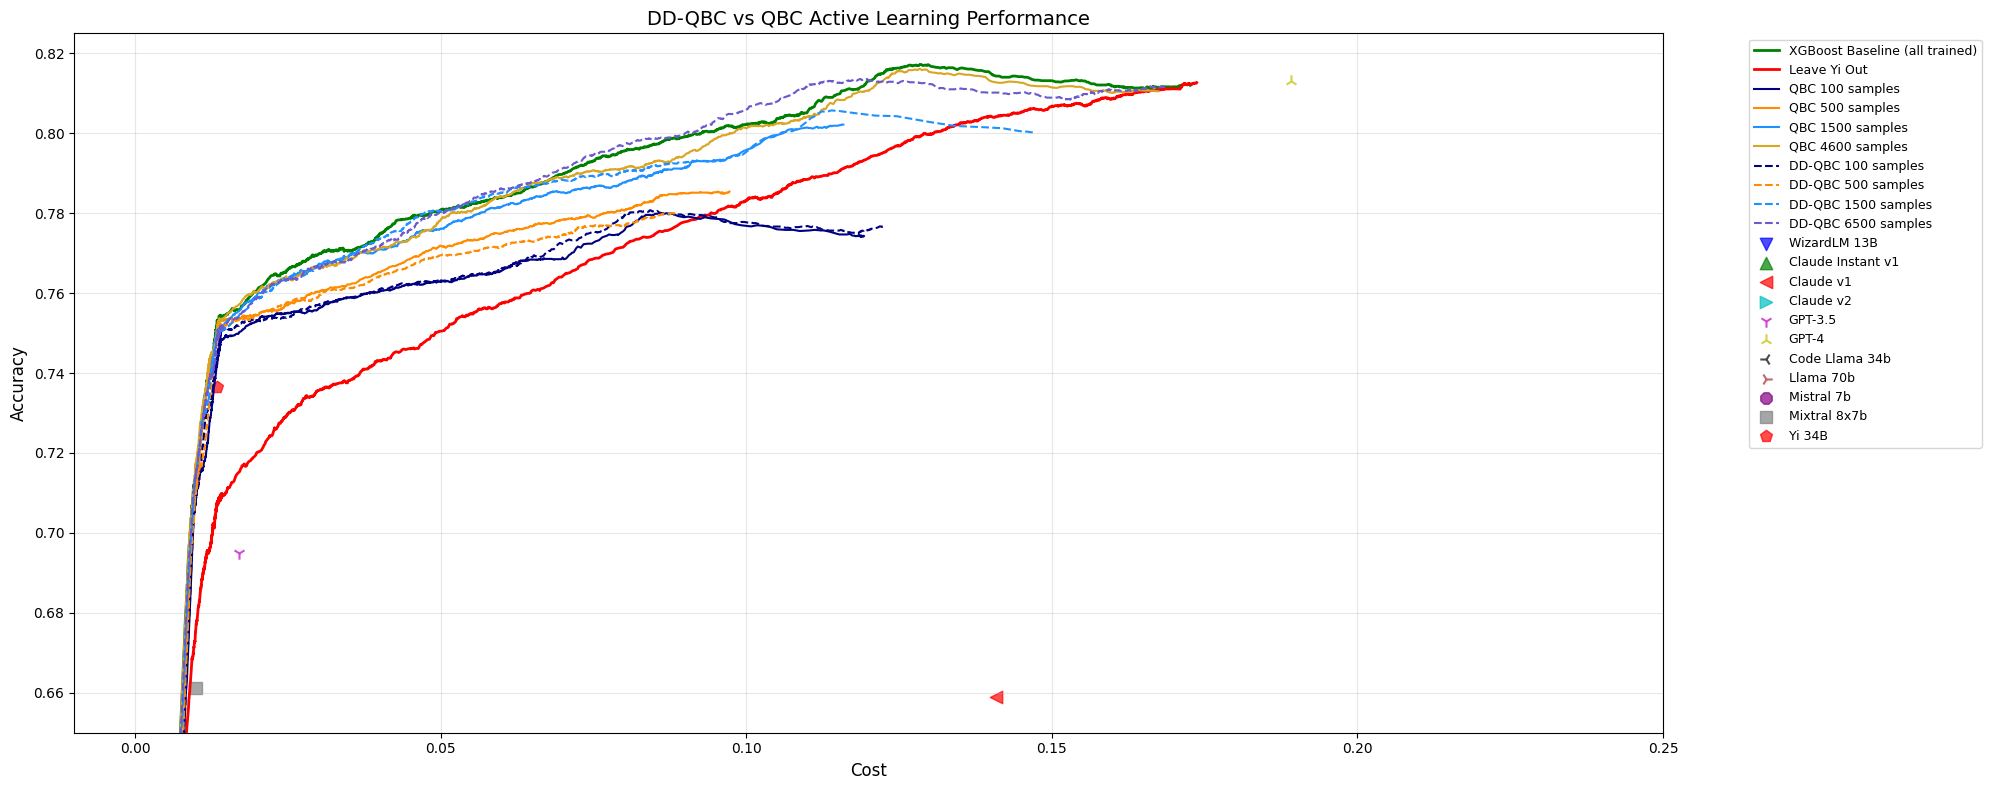

In [29]:
yi_name = 'zero-one-ai/Yi-34B-Chat'
yi_idx = llms.index(yi_name)

# baseline
y_acc_pred_xgb_baseline = xgb_multi.predict(x_test)

acc_xgb_baseline = np.zeros(len(lambdas))
cost_xgb_baseline = np.zeros(len(lambdas))
for i, lam in enumerate(lambdas):
    acc_xgb_baseline[i], cost_xgb_baseline[i] = score_auc(
        y_acc_test, y_cost_test, y_acc_pred_xgb_baseline, y_cost_test, lam
    )

# leave yi out
y_acc_pred_leave_out = np.zeros_like(y_acc_test, dtype=float)
for j in range(y_acc_test.shape[1]):
    if j != yi_idx:
        y_acc_pred_leave_out[:, j] = y_acc_pred_xgb_baseline[:, j]

acc_leave_out = np.zeros(len(lambdas))
cost_leave_out = np.zeros(len(lambdas))
for i, lam in enumerate(lambdas):
    acc_leave_out[i], cost_leave_out[i] = score_auc(
        y_acc_test, y_cost_test, y_acc_pred_leave_out, y_cost_test, lam
    )

def load_and_eval(directory, n_samples):
    path = f"{directory}/Yi_34B_{n_samples}.pkl"
    if not os.path.exists(path):
        print(f"[missing] {path}")
        return None
    with open(path, "rb") as f:
        ckpt = pickle.load(f)
    committee = ckpt["committee"] if isinstance(ckpt, dict) and "committee" in ckpt else ckpt
    preds = np.stack([m.predict(x_test) for m in committee], axis=1)
    ensemble_pred = preds.mean(axis=1)
    y_acc_pred = y_acc_pred_leave_out.copy()
    y_acc_pred[:, yi_idx] = ensemble_pred
    acc_curve = np.zeros(len(lambdas))
    cost_curve = np.zeros(len(lambdas))
    for i, lam in enumerate(lambdas):
        acc_curve[i], cost_curve[i] = score_auc(
            y_acc_test, y_cost_test, y_acc_pred, y_cost_test, lam
      )
    return acc_curve, cost_curve

# --- QBC ---
qbc_sizes = [100, 500, 1500, 4600]
qbc_curves = {}
for n in qbc_sizes:
    result = load_and_eval("qbc_xgb_important", n)
    if result is not None:
        qbc_curves[n] = result

# --- DD-QBC ---
ddqbc_sizes = [100, 500, 1500, 6500]
ddqbc_curves = {}
for n in ddqbc_sizes:
    result = load_and_eval("ddqbc_XGB_checkpoints_yi", n)
    if result is not None:
        ddqbc_curves[n] = result

# --- Plot ---
plt.figure(figsize=(20, 8))
plt.ylim(0.65, 0.825)
plt.xlim(-0.01, 0.25)

plt.plot(cost_xgb_baseline, acc_xgb_baseline, '-', color='green',
       label='XGBoost Baseline (all trained)', linewidth=2)
plt.plot(cost_leave_out, acc_leave_out, '-', color='red',
       label='Leave Yi Out', linewidth=2)

qbc_colors = ['navy', 'darkorange', 'dodgerblue', 'goldenrod']
for i, n in enumerate(qbc_sizes):
    if n in qbc_curves:
        acc_curve, cost_curve = qbc_curves[n]
        plt.plot(cost_curve, acc_curve, '-',
               color=qbc_colors[i],
               label=f'QBC {n} samples',
               linewidth=1.5)

ddqbc_colors = ['navy', 'darkorange', 'dodgerblue', 'slateblue']
for i, n in enumerate(ddqbc_sizes):
    if n in ddqbc_curves:
        acc_curve, cost_curve = ddqbc_curves[n]
        plt.plot(cost_curve, acc_curve, '--',
               color=ddqbc_colors[i],
               label=f'DD-QBC {n} samples',
               linewidth=1.5)

markers = ['v', '^', '<', '>', '1', '2', '3', '4', '8', 's', 'p']
colors_llms = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'brown', 'purple', 'gray', 'red']
for j, _ in enumerate(llms):
    avg_acc = np.mean(y_acc_test[:, j])
    avg_cost = np.mean(y_cost_test[:, j]) / np.max(y_cost_test)
    plt.scatter(avg_cost, avg_acc, marker=markers[j],
              color=colors_llms[j], s=80, alpha=0.7, label=llms_short[j])

plt.xlabel('Cost', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('DD-QBC vs QBC Active Learning Performance', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

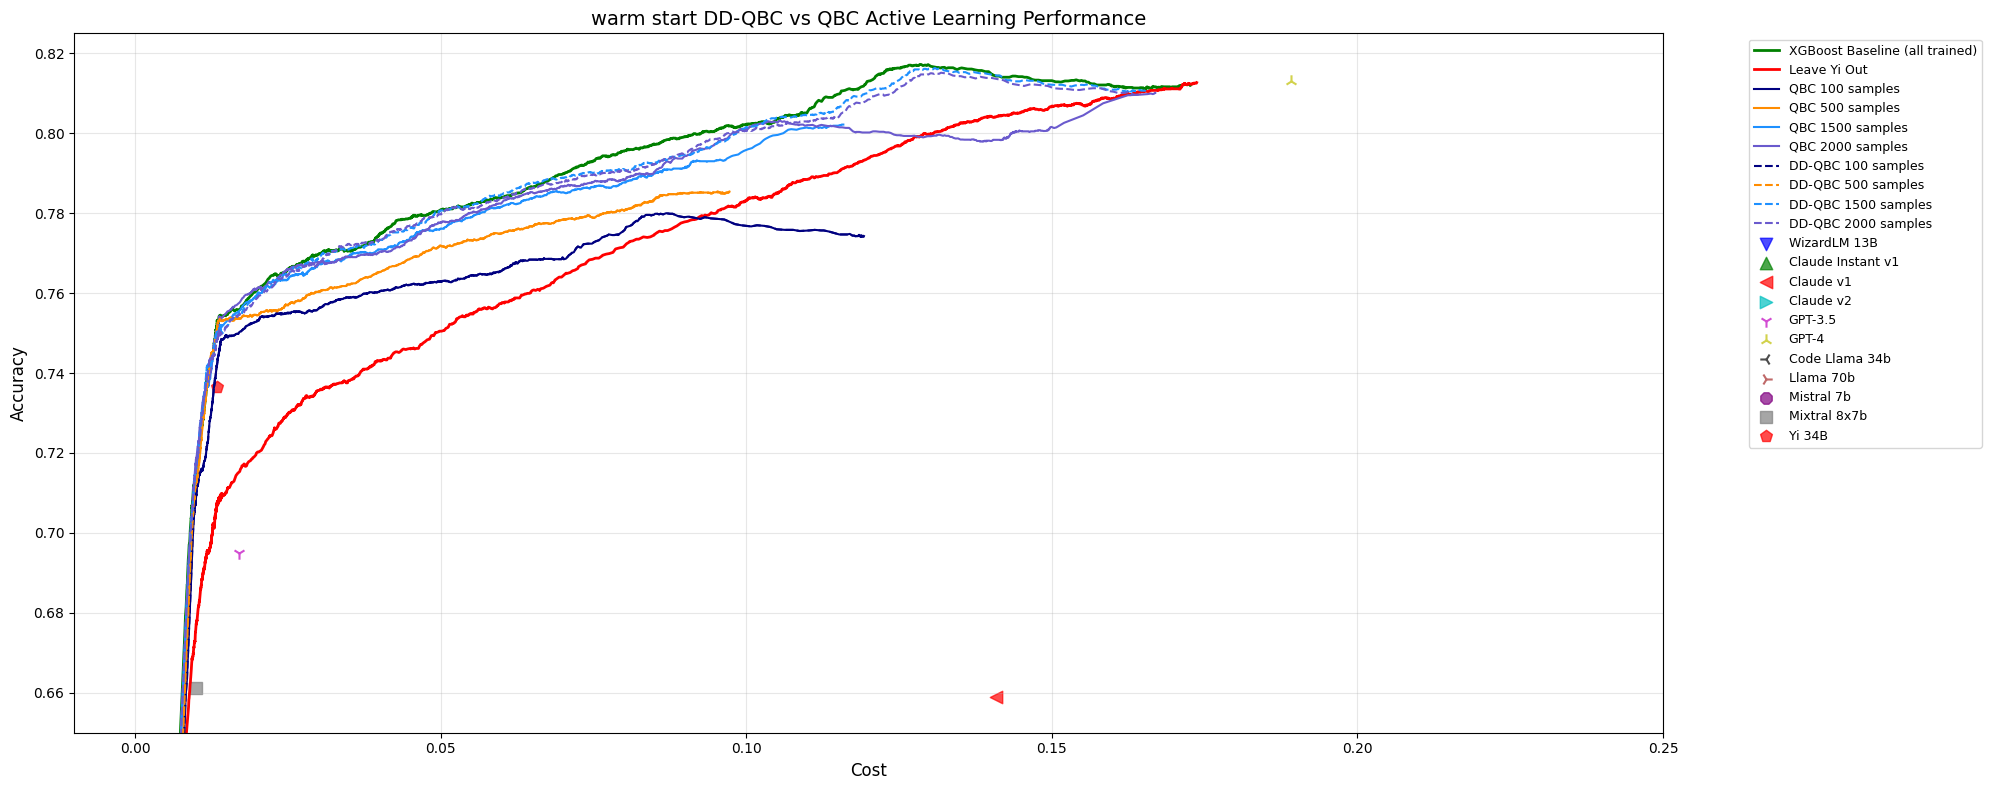

In [8]:
yi_name = 'zero-one-ai/Yi-34B-Chat'
yi_idx = llms.index(yi_name)

# baseline
y_acc_pred_xgb_baseline = xgb_multi.predict(x_test)

acc_xgb_baseline = np.zeros(len(lambdas))
cost_xgb_baseline = np.zeros(len(lambdas))
for i, lam in enumerate(lambdas):
    acc_xgb_baseline[i], cost_xgb_baseline[i] = score_auc(
        y_acc_test, y_cost_test, y_acc_pred_xgb_baseline, y_cost_test, lam
    )

# leave yi out
y_acc_pred_leave_out = np.zeros_like(y_acc_test, dtype=float)
for j in range(y_acc_test.shape[1]):
    if j != yi_idx:
        y_acc_pred_leave_out[:, j] = y_acc_pred_xgb_baseline[:, j]

acc_leave_out = np.zeros(len(lambdas))
cost_leave_out = np.zeros(len(lambdas))
for i, lam in enumerate(lambdas):
    acc_leave_out[i], cost_leave_out[i] = score_auc(
        y_acc_test, y_cost_test, y_acc_pred_leave_out, y_cost_test, lam
    )

def load_and_eval(directory, n_samples):
    path = f"{directory}/Yi_34B_{n_samples}.pkl"
    if not os.path.exists(path):
        print(f"[missing] {path}")
        return None
    with open(path, "rb") as f:
        ckpt = pickle.load(f)
    committee = ckpt["committee"] if isinstance(ckpt, dict) and "committee" in ckpt else ckpt
    preds = np.stack([m.predict(x_test) for m in committee], axis=1)
    ensemble_pred = preds.mean(axis=1)
    y_acc_pred = y_acc_pred_leave_out.copy()
    y_acc_pred[:, yi_idx] = ensemble_pred
    acc_curve = np.zeros(len(lambdas))
    cost_curve = np.zeros(len(lambdas))
    for i, lam in enumerate(lambdas):
        acc_curve[i], cost_curve[i] = score_auc(
            y_acc_test, y_cost_test, y_acc_pred, y_cost_test, lam
      )
    return acc_curve, cost_curve

qbc_sizes = [100, 500, 1500, 2000]
qbc_curves = {}
for n in qbc_sizes:
    result = load_and_eval("qbc_xgb_important", n)
    if result is not None:
        qbc_curves[n] = result

ddqbc_sizes = [100, 500, 1500, 2000]
ddqbc_curves = {}
for n in ddqbc_sizes:
    result = load_and_eval("warmstart_ddqbc_XGB_checkpoints_yi_42", n)
    if result is not None:
        ddqbc_curves[n] = result

plt.figure(figsize=(20, 8))
plt.ylim(0.65, 0.825)
plt.xlim(-0.01, 0.25)

plt.plot(cost_xgb_baseline, acc_xgb_baseline, '-', color='green',
       label='XGBoost Baseline (all trained)', linewidth=2)
plt.plot(cost_leave_out, acc_leave_out, '-', color='red',
       label='Leave Yi Out', linewidth=2)

qbc_colors = ['navy', 'darkorange', 'dodgerblue', 'slateblue']
for i, n in enumerate(qbc_sizes):
    if n in qbc_curves:
        acc_curve, cost_curve = qbc_curves[n]
        plt.plot(cost_curve, acc_curve, '-',
               color=qbc_colors[i],
               label=f'QBC {n} samples',
               linewidth=1.5)

ddqbc_colors = ['navy', 'darkorange', 'dodgerblue', 'slateblue']
for i, n in enumerate(ddqbc_sizes):
    if n in ddqbc_curves:
        acc_curve, cost_curve = ddqbc_curves[n]
        plt.plot(cost_curve, acc_curve, '--',
               color=ddqbc_colors[i],
               label=f'DD-QBC {n} samples',
               linewidth=1.5)

markers = ['v', '^', '<', '>', '1', '2', '3', '4', '8', 's', 'p']
colors_llms = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'brown', 'purple', 'gray', 'red']
for j, _ in enumerate(llms):
    avg_acc = np.mean(y_acc_test[:, j])
    avg_cost = np.mean(y_cost_test[:, j]) / np.max(y_cost_test)
    plt.scatter(avg_cost, avg_acc, marker=markers[j],
              color=colors_llms[j], s=80, alpha=0.7, label=llms_short[j])

plt.xlabel('Cost', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('warm start DD-QBC vs QBC Active Learning Performance', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

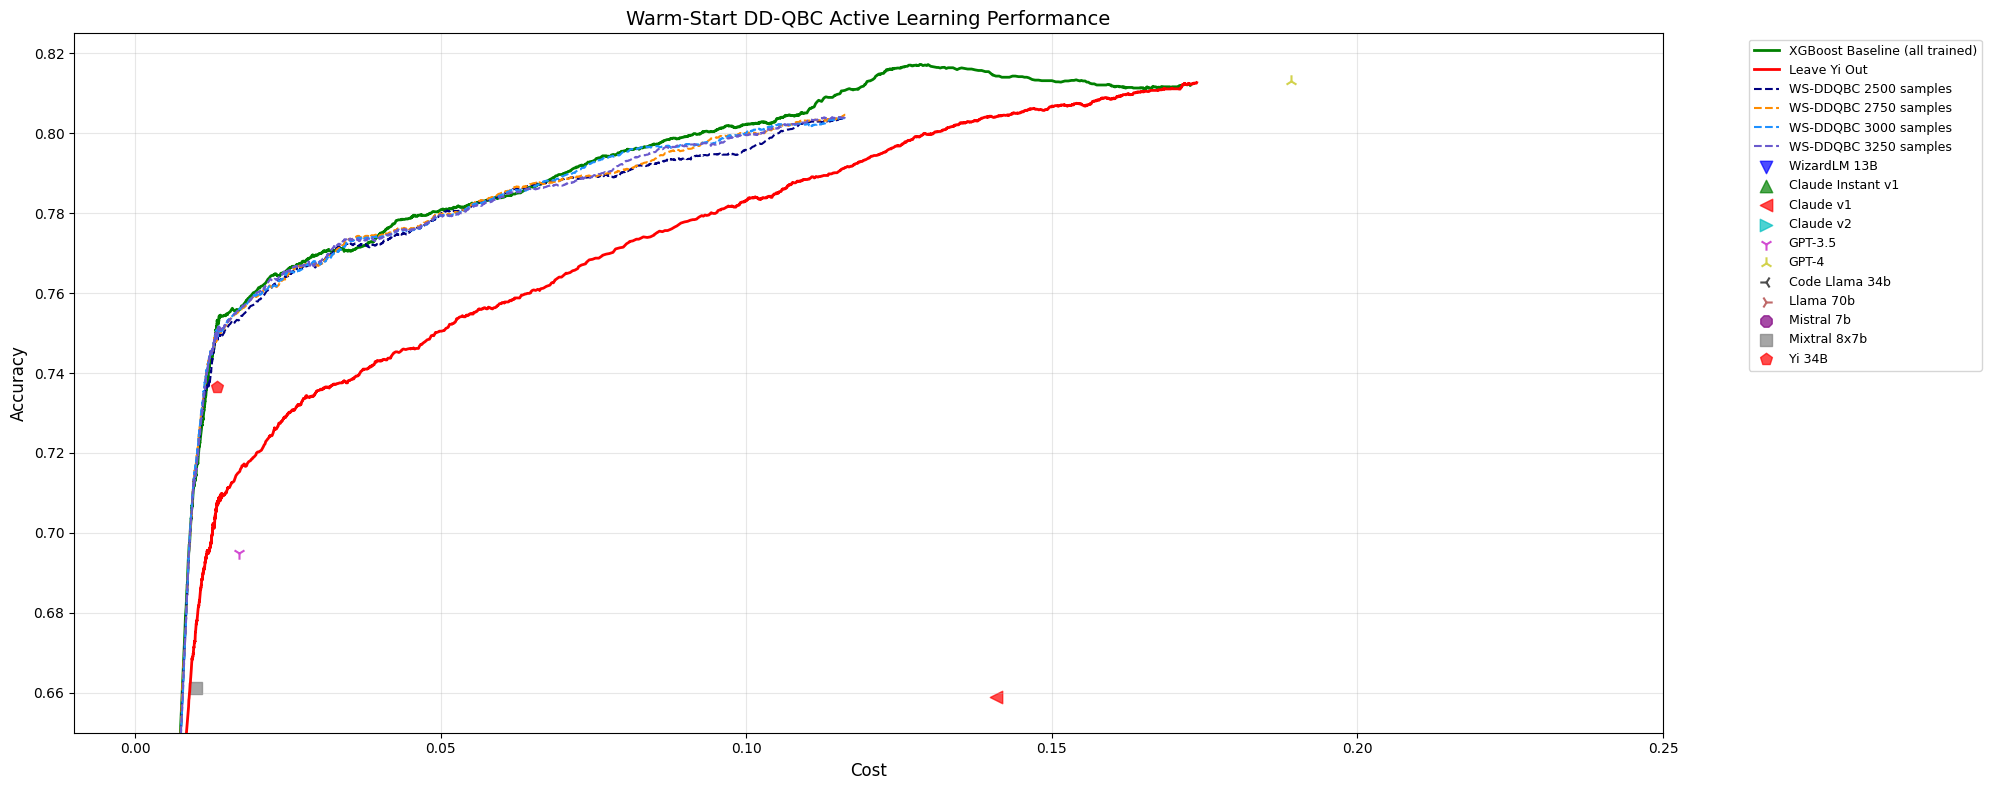

In [19]:
yi_name = 'zero-one-ai/Yi-34B-Chat'
yi_idx = llms.index(yi_name)

# baseline
y_acc_pred_xgb_baseline = xgb_multi.predict(x_test)

acc_xgb_baseline = np.zeros(len(lambdas))
cost_xgb_baseline = np.zeros(len(lambdas))
for i, lam in enumerate(lambdas):
    acc_xgb_baseline[i], cost_xgb_baseline[i] = score_auc(
        y_acc_test, y_cost_test, y_acc_pred_xgb_baseline, y_cost_test, lam
    )

y_acc_pred_leave_out = np.zeros_like(y_acc_test, dtype=float)
for j in range(y_acc_test.shape[1]):
    if j != yi_idx:
        y_acc_pred_leave_out[:, j] = y_acc_pred_xgb_baseline[:, j]

acc_leave_out = np.zeros(len(lambdas))
cost_leave_out = np.zeros(len(lambdas))
for i, lam in enumerate(lambdas):
    acc_leave_out[i], cost_leave_out[i] = score_auc(
        y_acc_test, y_cost_test, y_acc_pred_leave_out, y_cost_test, lam
    )

def load_and_eval(directory, n_samples):
    path = f"{directory}/Yi_34B_{n_samples}.pkl"
    if not os.path.exists(path):
        print(f"[missing] {path}")
        return None
    with open(path, "rb") as f:
        ckpt = pickle.load(f)
    committee = ckpt["committee"] if isinstance(ckpt, dict) and "committee" in ckpt else ckpt
    preds = np.stack([m.predict(x_test) for m in committee], axis=1)
    ensemble_pred = preds.mean(axis=1)
    y_acc_pred = y_acc_pred_leave_out.copy()
    y_acc_pred[:, yi_idx] = ensemble_pred
    acc_curve = np.zeros(len(lambdas))
    cost_curve = np.zeros(len(lambdas))
    for i, lam in enumerate(lambdas):
        acc_curve[i], cost_curve[i] = score_auc(
            y_acc_test, y_cost_test, y_acc_pred, y_cost_test, lam
        )
    return acc_curve, cost_curve

ws_sizes = [2500, 2750, 3000, 3250]
ws_curves = {}
for n in ws_sizes:
    result = load_and_eval("warmstart_ddqbc_XGB_checkpoints_yi_42", n)
    if result is not None:
        ws_curves[n] = result

plt.figure(figsize=(20, 8))
plt.ylim(0.65, 0.825)
plt.xlim(-0.01, 0.25)

plt.plot(cost_xgb_baseline, acc_xgb_baseline, '-', color='green',
         label='XGBoost Baseline (all trained)', linewidth=2)
plt.plot(cost_leave_out, acc_leave_out, '-', color='red',
         label='Leave Yi Out', linewidth=2)

ws_colors = ['navy', 'darkorange', 'dodgerblue', 'slateblue']
for i, n in enumerate(ws_sizes):
    if n in ws_curves:
        acc_curve, cost_curve = ws_curves[n]
        plt.plot(cost_curve, acc_curve, '--',
                 color=ws_colors[i],
                 label=f'WS-DDQBC {n} samples',
                 linewidth=1.5)

markers = ['v', '^', '<', '>', '1', '2', '3', '4', '8', 's', 'p']
colors_llms = ['b', 'g', 'r', 'c', 'm', 'y', 'k', 'brown', 'purple', 'gray', 'red']
for j, _ in enumerate(llms):
    avg_acc = np.mean(y_acc_test[:, j])
    avg_cost = np.mean(y_cost_test[:, j]) / np.max(y_cost_test)
    plt.scatter(avg_cost, avg_acc, marker=markers[j],
                color=colors_llms[j], s=80, alpha=0.7, label=llms_short[j])

plt.xlabel('Cost', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Warm-Start DD-QBC Active Learning Performance', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

In [8]:
from skactiveml.regressor import SklearnRegressor
from skactiveml.pool import QueryByCommittee
from xgboost import XGBRegressor

def WarmStart_DDQBC(
    x_train, y_train, y_cost_train, y_pred_baseline_train, directory,
    initial_batch_size=50, batch_size=50, save_interval=1,
    random_state=42, n_committee=10, n_iterations=200,
    llms=None, yi_name='zero-one-ai/Yi-34B-Chat',
    tau=1.0, epsilon=0.0,
    lambdas_acq=None,
    warmup_samples=500,
):
    """
    Warm-start DD-QBC: use standard QBC for the first `warmup_samples`,
    then switch to DD-QBC acquisition for the rest.
    """
    os.makedirs(directory, exist_ok=True)

    yi_idx = llms.index(yi_name)
    y_true = y_train[:, yi_idx].astype(float)
    y_labeled = np.full_like(y_true, np.nan, dtype=float)

    np.random.seed(random_state)
    initial_indices = np.random.choice(len(y_true), initial_batch_size, replace=False)
    y_labeled[initial_indices] = y_true[initial_indices]

    # Committee creation
    committee = []
    for i in range(n_committee):
        xgb_model = XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=random_state + i,
        )
        committee.append(SklearnRegressor(xgb_model, missing_label=np.nan))

    def retrain_committee(iter_no: int):
        labeled_indices = np.where(~np.isnan(y_labeled))[0]
        for i, model in enumerate(committee):
            rng = np.random.RandomState(random_state + i + iter_no * 1000)
            boot = rng.choice(labeled_indices, len(labeled_indices), replace=True)
            model.fit(x_train[boot], y_labeled[boot])

    def save_checkpoint(n_labeled):
        path = f"{directory}/Yi_34B_{n_labeled}.pkl"
        with open(path, "wb") as f:
            pickle.dump(committee, f)

    if lambdas_acq is None:
        lambdas_acq = np.arange(0, 1.001, 0.0001)

    y_cost_train_norm = y_cost_train / np.max(y_cost_train)
    old_indices = [j for j in range(y_pred_baseline_train.shape[1]) if j != yi_idx]
    baseline_preds_no_yi = y_pred_baseline_train[:, old_indices]
    cost_norm_no_yi = y_cost_train_norm[:, old_indices]
    yi_cost_norm = y_cost_train_norm[:, yi_idx]

    warmup_iters = max(0, (warmup_samples - initial_batch_size) // batch_size)

    retrain_committee(iter_no=0)
    save_checkpoint(n_labeled=initial_batch_size)

    qbc = QueryByCommittee(missing_label=np.nan)

    for it in range(n_iterations):
        remaining_unlabeled = np.sum(np.isnan(y_labeled))
        if remaining_unlabeled == 0:
            break

        actual_batch_size = min(batch_size, int(remaining_unlabeled))
        use_qbc = (it < warmup_iters)

        if use_qbc:
            query_idx = qbc.query(
                X=x_train,
                y=y_labeled,
                ensemble=committee,
                fit_ensemble=False,
                batch_size=actual_batch_size
            )
            query_idx = np.atleast_1d(query_idx).astype(int)
        else:
            committee_preds = np.stack([m.predict(x_train) for m in committee], axis=1)

            unlabeled_indices = np.where(np.isnan(y_labeled))[0]
            n_unlabeled = len(unlabeled_indices)

            comm_preds_u = committee_preds[unlabeled_indices]
            baseline_u = baseline_preds_no_yi[unlabeled_indices]
            cost_u_old = cost_norm_no_yi[unlabeled_indices]
            yi_cost_u = yi_cost_norm[unlabeled_indices]

            dd_scores = np.zeros(n_unlabeled, dtype=np.float64)

            for lam in lambdas_acq:
                lam_f = float(lam)

                existing_utilities = (1 - lam_f) * baseline_u - lam_f * cost_u_old
                best_existing = existing_utilities.max(axis=1)

                yi_utilities = (1 - lam_f) * comm_preds_u - lam_f * yi_cost_u[:, np.newaxis]

                p = (yi_utilities >= best_existing[:, np.newaxis]).astype(float).mean(axis=1)

                eps_log = 1e-12
                H = -p * np.log(p + eps_log) - (1 - p) * np.log(1 - p + eps_log)
                H[(p < eps_log) | (p > 1 - eps_log)] = 0.0

                yi_mean_utility = yi_utilities.mean(axis=1)
                delta = yi_mean_utility - best_existing
                g = np.minimum(np.abs(delta), tau)

                score_lam = H * g

                if epsilon > 0:
                    max_yi = yi_utilities.max(axis=1)
                    score_lam[max_yi < best_existing - epsilon] = 0.0

                dd_scores += score_lam

            dd_scores /= len(lambdas_acq)

            top_local = np.argsort(dd_scores)[::-1][:actual_batch_size]
            query_idx = unlabeled_indices[top_local]

        y_labeled[query_idx] = y_true[query_idx]
        retrain_committee(iter_no=it + 1)

        if (it + 1) % save_interval == 0:
            n_labeled = initial_batch_size + ((it + 1) * batch_size)
            phase = "QBC" if use_qbc else "DD-QBC"
            save_checkpoint(n_labeled=n_labeled)
            print(f"Iteration {it+1} [{phase}]: {n_labeled} samples saved")

In [ ]:
y_pred_baseline_train = xgb_multi.predict(x_train)

WarmStart_DDQBC(
    x_train=x_train,
    y_train=y_acc_train,
    y_cost_train=y_cost_train,
    y_pred_baseline_train=y_pred_baseline_train,
    directory=f'warmstart_ddqbc_XGB_checkpoints_yi_42',
    initial_batch_size=50,
    batch_size=50,
    save_interval=1,
    random_state=42,
    n_committee=10,
    n_iterations=100,
    llms=llms,
    yi_name='zero-one-ai/Yi-34B-Chat',
    tau=1.0,
    epsilon=0.0,
    lambdas_acq=lambdas,
    warmup_samples=100,
)

Iteration 1 [QBC]: 100 samples saved
Iteration 2 [QBC]: 150 samples saved
Iteration 3 [QBC]: 200 samples saved
Iteration 4 [QBC]: 250 samples saved
Iteration 5 [QBC]: 300 samples saved
Iteration 6 [QBC]: 350 samples saved
Iteration 7 [QBC]: 400 samples saved
Iteration 8 [QBC]: 450 samples saved
Iteration 9 [QBC]: 500 samples saved
Iteration 10 [DD-QBC]: 550 samples saved
Iteration 19 [DD-QBC]: 1000 samples saved
Iteration 20 [DD-QBC]: 1050 samples saved
Iteration 21 [DD-QBC]: 1100 samples saved
Iteration 22 [DD-QBC]: 1150 samples saved
Iteration 23 [DD-QBC]: 1200 samples saved
